# About The Dataset
The original source of the data is Australian Government's Bureau of Meteorology and the latest data can be gathered from [http://www.bom.gov.au/climate/dwo/](http://www.bom.gov.au/climate/dwo/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2022-01-01).

The dataset you'll use in this project was downloaded from Kaggle at [https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package/](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package?resource=download&select=weatherAUS.csv)  
Column definitions were gathered from [http://www.bom.gov.au/climate/dwo/IDCJDW0000.shtml](http://www.bom.gov.au/climate/dwo/IDCJDW0000.shtml?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2022-01-01)  

The dataset contains observations of weather metrics for each day from 2008 to 2017, and includes the following fields:

| Field         | Description                                           | Unit            | Type   |
| :------------ | :---------------------------------------------------- | :-------------- | :----- |
| Date          | Date of the Observation in YYYY-MM-DD                 | Date            | object |
| Location      | Location of the Observation                           | Location        | object |
| MinTemp       | Minimum temperature                                   | Celsius         | float  |
| MaxTemp       | Maximum temperature                                   | Celsius         | float  |
| Rainfall      | Amount of rainfall                                    | Millimeters     | float  |
| Evaporation   | Amount of evaporation                                 | Millimeters     | float  |
| Sunshine      | Amount of bright sunshine                             | hours           | float  |
| WindGustDir   | Direction of the strongest gust                       | Compass Points  | object |
| WindGustSpeed | Speed of the strongest gust                           | Kilometers/Hour | object |
| WindDir9am    | Wind direction averaged over 10 minutes prior to 9am  | Compass Points  | object |
| WindDir3pm    | Wind direction averaged over 10 minutes prior to 3pm  | Compass Points  | object |
| WindSpeed9am  | Wind speed averaged over 10 minutes prior to 9am      | Kilometers/Hour | float  |
| WindSpeed3pm  | Wind speed averaged over 10 minutes prior to 3pm      | Kilometers/Hour | float  |
| Humidity9am   | Humidity at 9am                                       | Percent         | float  |
| Humidity3pm   | Humidity at 3pm                                       | Percent         | float  |
| Pressure9am   | Atmospheric pressure reduced to mean sea level at 9am | Hectopascal     | float  |
| Pressure3pm   | Atmospheric pressure reduced to mean sea level at 3pm | Hectopascal     | float  |
| Cloud9am      | Fraction of the sky obscured by cloud at 9am          | Eights          | float  |
| Cloud3pm      | Fraction of the sky obscured by cloud at 3pm          | Eights          | float  |
| Temp9am       | Temperature at 9am                                    | Celsius         | float  |
| Temp3pm       | Temperature at 3pm                                    | Celsius         | float  |
| RainToday     | If there was at least 1mm of rain today               | Yes/No          | object |
| RainTomorrow  | If there is at least 1mm of rain tomorrow             | Yes/No          | object |



## Install and import the required libraries


In [ ]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

## Load the data


Execute the following cells to load the dataset as a pandas dataframe.


In [ ]:
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/_0eYOqji3unP1tDNKWZMjg/weatherAUS-2.csv"
df = pd.read_csv(url)
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [ ]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [ ]:
df.shape

(145460, 23)

In [ ]:
df.count()

,0
Date,145460
Location,145460
MinTemp,143975
MaxTemp,144199
Rainfall,142199
Evaporation,82670
Sunshine,75625
WindGustDir,135134
WindGustSpeed,135197
WindDir9am,134894


In [ ]:
df = df.drop(['Cloud9am', 'Cloud3pm', 'Sunshine'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   WindGustDir    135134 non-null  object 
 7   WindGustSpeed  135197 non-null  float64
 8   WindDir9am     134894 non-null  object 
 9   WindDir3pm     141232 non-null  object 
 10  WindSpeed9am   143693 non-null  float64
 11  WindSpeed3pm   142398 non-null  float64
 12  Humidity9am    142806 non-null  float64
 13  Humidity3pm    140953 non-null  float64
 14  Pressure9am    130395 non-null  float64
 15  Pressure3pm    130432 non-null  float64
 16  Temp9am        143693 non-null  float64
 17  Temp3pm        141851 non-nul

In [ ]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainToday',
       'RainTomorrow'],
      dtype='object')

In [ ]:
# I choose set of location to predict the rainfall.
df = df[df.Location.isin(['Melbourne','MelbourneAirport','Watsonia'])]
df. info()

<class 'pandas.core.frame.DataFrame'>
Index: 9211 entries, 64191 to 80997
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9211 non-null   object 
 1   Location       9211 non-null   object 
 2   MinTemp        8724 non-null   float64
 3   MaxTemp        8730 non-null   float64
 4   Rainfall       8443 non-null   float64
 5   Evaporation    9202 non-null   float64
 6   WindGustDir    9145 non-null   object 
 7   WindGustSpeed  9145 non-null   float64
 8   WindDir9am     8930 non-null   object 
 9   WindDir3pm     9151 non-null   object 
 10  WindSpeed9am   9207 non-null   float64
 11  WindSpeed3pm   9210 non-null   float64
 12  Humidity9am    8707 non-null   float64
 13  Humidity3pm    8715 non-null   float64
 14  Pressure9am    8729 non-null   float64
 15  Pressure3pm    8728 non-null   float64
 16  Temp9am        8716 non-null   float64
 17  Temp3pm        8727 non-null   float64
 18  RainToda

In [ ]:
# I rename the target column
df = df.rename(columns={'RainToday': 'RainYesterday',
                        'RainTomorrow': 'RainToday'
                        })

In [ ]:
# checkig the missing values
df.isnull().sum()

,0
Location,0
MinTemp,7
MaxTemp,1
Rainfall,146
Evaporation,6
WindGustDir,61
WindGustSpeed,61
WindDir9am,267
WindDir3pm,59
WindSpeed9am,3


In [ ]:
# determine the target column
X = df.drop('RainToday', axis=1)
y = df['RainToday']

In [ ]:
y.value_counts(dropna=False)

,count
RainToday,
No,6416
Yes,2027
NaN,768


In [ ]:
# I remove the missing value from the target column
df = df.dropna(subset=['RainToday'])
y.isnull().sum()


np.int64(768)

In [ ]:
# Encode the target variable 'y'
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:

# Create Season columns on the date
def date_to_season(date):
    month = date.month
    if (month == 12) or (month == 1) or (month == 2):
        return 'Summer'
    elif (month == 3) or (month == 4) or (month == 5):
        return 'Autumn'
    elif (month == 6) or (month == 7) or (month == 8):
        return 'Winter'
    elif (month == 9) or (month == 10) or (month == 11):
        return 'Spring'

In [ ]:
# converting the date to datetime type
df['Date'] = pd.to_datetime(df['Date'])
df['Season'] = df['Date'].apply(date_to_season)
df=df.drop(columns='Date')
df

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainYesterday,RainToday,Season
64191,MelbourneAirport,11.2,19.9,0.0,5.6,SW,69.0,W,SW,33.0,43.0,55.0,37.0,1005.1,1006.4,15.9,18.1,No,Yes,Summer
64192,MelbourneAirport,7.8,17.8,1.2,7.2,SSE,56.0,SW,SSE,31.0,26.0,50.0,43.0,1018.0,1019.3,12.5,15.8,Yes,No,Summer
64193,MelbourneAirport,6.3,21.1,0.0,6.2,SSE,31.0,E,S,13.0,19.0,51.0,35.0,1020.8,1017.6,13.4,19.6,No,No,Summer
64194,MelbourneAirport,8.1,29.2,0.0,6.4,SSE,35.0,NE,SSE,2.0,20.0,67.0,23.0,1016.2,1012.8,16.0,28.2,No,No,Summer
64195,MelbourneAirport,9.7,29.0,0.0,7.4,SE,33.0,SW,SSE,9.0,20.0,51.0,31.0,1011.9,1010.3,19.4,27.1,No,No,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80993,Watsonia,5.2,13.6,0.0,0.6,N,20.0,NaN,WSW,0.0,7.0,100.0,83.0,1028.9,1028.5,9.8,12.7,No,No,Winter
80994,Watsonia,4.8,13.3,0.4,0.6,NNW,24.0,NE,NNE,2.0,11.0,100.0,63.0,1028.5,1025.1,5.6,12.4,No,No,Winter
80995,Watsonia,5.6,13.1,0.0,1.6,NNW,52.0,NE,N,11.0,20.0,85.0,67.0,1019.0,1014.0,8.8,11.6,No,Yes,Winter
80996,Watsonia,6.9,12.1,3.2,1.8,SSW,24.0,WNW,SW,9.0,11.0,99.0,61.0,1018.7,1017.3,7.9,11.0,Yes,No,Winter


In [ ]:
# Traing and test the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
# classify the numeric and categorical data type
numeric_features = X_train.select_dtypes(include=['int', 'float']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
#numeric_features
#categorical_features

In [ ]:
# Applying preprocessing imputation to handle missing values
from sklearn.impute import SimpleImputer

# Scale the numeric features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# One-hot encode the categoricals, ensuring dense output
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

#numeric_transformer
categorical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [ ]:
# creating transfor columns to combine the numeric and categrical vlaues
preprocesser = ColumnTransformer(
    transformers = [('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)])
preprocesser

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['MinTemp', 'MaxTemp', 'Rainfall',
                                  'Evaporation', 'WindGustSpeed',
                                  'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
                                  'Humidity3pm', 'Pressure9am', 'Pressure3pm',
                                  'Temp9am', 'Temp3pm']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Location', 'WindGustDir', 'WindDir9am',
                                  'WindDir3pm', 'RainYesterday', 'Season'])])

In [ ]:
# creating Pipeline for clear process and productive predicting
pipeline = Pipeline(steps=[('preprocesser', preprocesser),
           ('model', RandomForestClassifier(random_state=42))
                          ])
pipeline

Pipeline(steps=[('preprocesser',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Temp9am', 'Temp3pm']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am', 'WindDir3pm',
                                                   'RainYesterday',
                                                   'Season'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [ ]:
# makeing parameters for the random forset
param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

In [ ]:
# Creating cross validation with 5 folds
cv = StratifiedKFold(n_splits=5, shuffle=True)

In [ ]:
# using gridsearch optimization
grc = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=cv, scoring='f1', verbose=2)
grc.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=50; total time=   0.6s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=50; total time=   0.6s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=50; total time=   0.6s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=50; total time=   0.6s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=50; total time=   0.6s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   1.6s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   1.6s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   1.2s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   1.2s
[CV] END

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('preprocesser',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['MinTemp',
                                                                          'MaxTemp',
                                                                          'Rainfall',
                                                                          'Evaporation',
                                                                          'WindGustSpeed',
                                                                          'WindSpeed9am',
                                                                          'WindSpeed3pm',
                                                                          'Humidity9am',
                                                                          'Humidity3pm',...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['Location',
                                                                          'WindGustDir',
                                                                          'WindDir9am',
                                                                          'WindDir3pm',
                                                                          'RainYesterday',
                                                                          'Season'])])),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [50, 100]},
             scoring='f1', verbose=2)

In [ ]:
# displing the best parameters
print("\nBest parameters found: ", grc.best_params_)
print("Best cross-validation score: {:.2f}".format(grc.best_score_))


Best parameters found:  {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best cross-validation score: 0.60


In [ ]:
# Getting the scoring of the optimaization
test_score = grc.score(X_test, y_test)
print("Test set score: {:.2f}".format(test_score))

Test set score: 0.62


In [ ]:
# Testing the model on hiddin unseen data
y_pred = grc.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 1, 0])

              precision    recall  f1-score   support

           0       0.87      0.97      0.91      1284
           1       0.83      0.53      0.64       405

    accuracy                           0.86      1689
   macro avg       0.85      0.75      0.78      1689
weighted avg       0.86      0.86      0.85      1689

0.8602723505032563


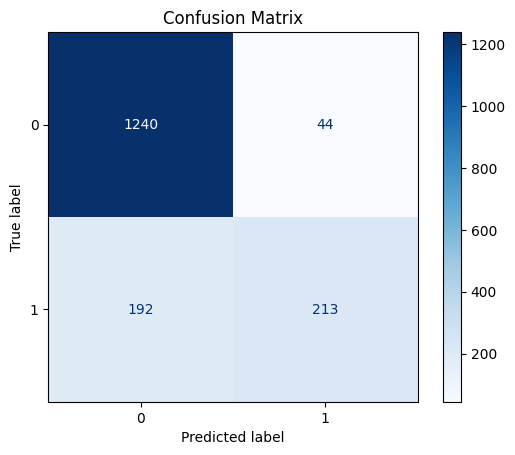

In [ ]:
# Showing the result of the the prediction and the visualizing it by conf-metrix
from sklearn.metrics import accuracy_score
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Greens')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Extracting the importance featurs
feature_importances = grc.best_estimator_['model'].feature_importances_
feature_importances

array([0.0482149 , 0.05074406, 0.04291189, 0.04170003, 0.05462685,
       0.03862512, 0.03808238, 0.04416601, 0.13837385, 0.09789204,
       0.08595396, 0.04687457, 0.05891095, 0.00724742, 0.00715171,
       0.00550199, 0.00108338, 0.00141695, 0.00058124, 0.00705319,
       0.00119743, 0.00322885, 0.00418821, 0.00251398, 0.00379673,
       0.0010879 , 0.00324193, 0.00420719, 0.00430787, 0.00446604,
       0.002159  , 0.00408624, 0.00123487, 0.00232979, 0.00083896,
       0.00770764, 0.00339092, 0.00387716, 0.00348321, 0.00205392,
       0.00209946, 0.00085407, 0.00174057, 0.00259309, 0.0031316 ,
       0.00490217, 0.00299122, 0.00456857, 0.00090785, 0.00139085,
       0.00043858, 0.00690062, 0.00264522, 0.00422654, 0.00477945,
       0.00357711, 0.00528765, 0.00133514, 0.00530955, 0.00447595,
       0.00441846, 0.00330737, 0.00303242, 0.00340354, 0.00686012,
       0.00888405, 0.00669214, 0.00668795, 0.00631698, 0.00573139])

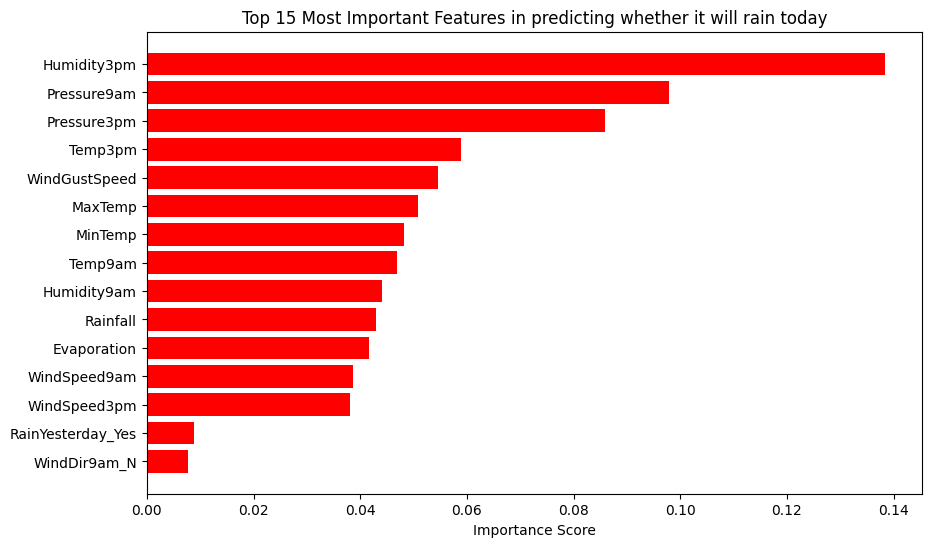

In [ ]:
# Combining numeric and categorical feature names
feature_names = numeric_features + list(grc.best_estimator_['preprocesser']
                                        .named_transformers_['cat']
                                        .named_steps['onehot']
                                        .get_feature_names_out(categorical_features))

feature_importances = grc.best_estimator_['model'].feature_importances_

importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importances
                             }).sort_values(by='Importance', ascending=False)

N = 15  # Change this number to display more or fewer features
top_features = importance_df.head(N)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='red')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature on top
plt.title(f'Top {N} Most Important Features in predicting whether it will rain today')
plt.xlabel('Importance Score')
plt.show()

In [ ]:
# applying logistic regression to get more experimet on multiple models
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline(steps=[
    ('preprocesser', preprocesser),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

param_grid = {
    'model__solver': ['liblinear'],
    'model__penalty': ['l1', 'l2'],
    'model__class_weight': [None, 'balanced']
}

grc = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    verbose=2
)

grc.fit(X_train, y_train)

y_pred = grc.best_estimator_.predict(X_test)
pipeline


Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END model__class_weight=None, model__penalty=l1, model__solver=liblinear; total time=   0.2s
[CV] END model__class_weight=None, model__penalty=l1, model__solver=liblinear; total time=   0.2s
[CV] END model__class_weight=None, model__penalty=l1, model__solver=liblinear; total time=   0.2s
[CV] END model__class_weight=None, model__penalty=l1, model__solver=liblinear; total time=   0.2s
[CV] END model__class_weight=None, model__penalty=l1, model__solver=liblinear; total time=   0.2s
[CV] END model__class_weight=None, model__penalty=l2, model__solver=liblinear; total time=   0.1s
[CV] END model__class_weight=None, model__penalty=l2, model__solver=liblinear; total time=   0.1s
[CV] END model__class_weight=None, model__penalty=l2, model__solver=liblinear; total time=   0.1s
[CV] END model__class_weight=None, model__penalty=l2, model__solver=liblinear; total time=   0.1s
[CV] END model__class_weight=None, model__penalty=l2, mode

Pipeline(steps=[('preprocesser',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Temp9am', 'Temp3pm']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am', 'WindDir3pm',
                                                   'RainYesterday',
                                                   'Season'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

              precision    recall  f1-score   support

           0       0.91      0.79      0.84      1284
           1       0.53      0.74      0.61       405

    accuracy                           0.78      1689
   macro avg       0.72      0.76      0.73      1689
weighted avg       0.81      0.78      0.79      1689



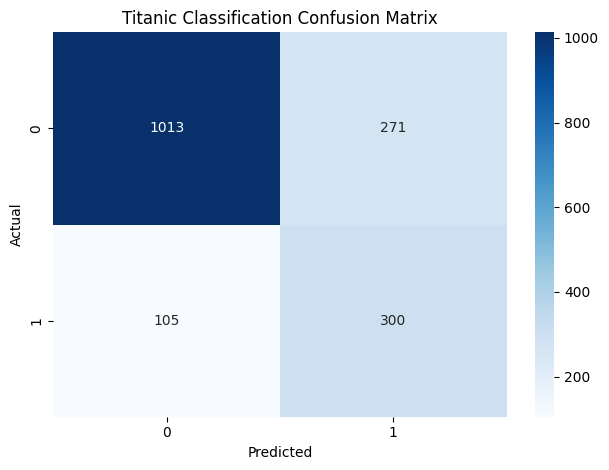

In [ ]:
# gettning  the result of the lr
print(classification_report(y_test, y_pred))

# for the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')

# the title and labels
plt.title('Titanic Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# the plot
plt.tight_layout()
plt.show()